# Avaliando um modelo de classificação
- No excel **"BaseInadimplencia.xlsx"** temos 2 abas:
    - **treino**: dados de treine
    - **teste**: dados de teste

### Importando e visualizando a base

In [1]:
# Importando o pandas e a base
import pandas as pd


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
treino = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/hastag/curso_youtube_lucas/07-18 - Avaliando um Modelo de Classificação/BaseInadimplencia.xlsx",sheet_name='treino')
teste = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/hastag/curso_youtube_lucas/07-18 - Avaliando um Modelo de Classificação/BaseInadimplencia.xlsx",sheet_name='teste')

In [4]:
treino.head(2)

,SaldoConta,SaldoInvestimento,Situacao
0,-1.365390,-3.280278,0
1,-3.910816,-0.874096,0


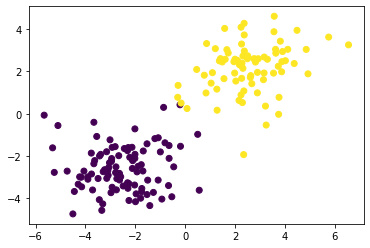

In [5]:
# Criando uma reta capaz de separar esses pontos
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.scatter(teste.SaldoConta, teste.SaldoInvestimento,c=teste.Situacao)

plt.show()

### Criando dois modelos de classificação e utilizando nos dados de teste

In [6]:
# Dados de treino
X_treino = treino.drop('Situacao',axis=1)
y_treino = treino.Situacao

# Dados de teste
X_teste = teste.drop('Situacao',axis=1)
y_teste = teste.Situacao

#### Regressão Logística

In [7]:
# Importando a regressão logística
from sklearn.linear_model import LogisticRegression

# Criando o classificador
clfLR = LogisticRegression(random_state=0).fit(X_treino, y_treino)

# Fazendo o predict nos dados de treino
treino['y_RegLog'] = clfLR.predict(X_treino)

# Fazendo o predict nos dados de teste
teste['y_RegLog'] = clfLR.predict(X_teste)

In [8]:
teste.head(2)

,SaldoConta,SaldoInvestimento,Situacao,y_RegLog
0,-1.992492,-4.158429,0,0
1,-3.306014,-4.261263,0,0


#### Árvore de Decisão

In [9]:
# Importando a árvore de decisão
from sklearn.tree import DecisionTreeClassifier

# Criando o classificador
clfDT = DecisionTreeClassifier(random_state=0).fit(X_treino, y_treino)

# Fazendo o predict nos dados de treino
treino['y_Arvore'] = clfDT.predict(X_treino)

# Fazendo o predict nos dados de teste
teste['y_Arvore'] = clfDT.predict(X_teste)

In [10]:
teste.head(2)

,SaldoConta,SaldoInvestimento,Situacao,y_RegLog,y_Arvore
0,-1.992492,-4.158429,0,0,0
1,-3.306014,-4.261263,0,0,0


### Avaliando o modelo criado
- Para avaliar o modelo, vamos começar utilizando a matriz de confusão (confusion matrix)
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [11]:
from sklearn.metrics import confusion_matrix

![imagem.png](attachment:imagem.png)

In [12]:
# Reg Log
confusion_matrix(teste.Situacao,teste.y_RegLog)

array([[98,  1],
       [ 0, 79]])

In [13]:
# Árore de Decisão
confusion_matrix(teste.Situacao,teste.y_Arvore)

array([[97,  2],
       [ 1, 78]])

- Vamos calcular a acurácia
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score

In [14]:
# A = VP + VN / (TOTAL)
(98+79)/(98+79+1+0)

0.9943820224719101

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
# Reg Log
accuracy_score(teste.Situacao,teste.y_RegLog)

0.9943820224719101

In [17]:
# Árore de Decisão
accuracy_score(teste.Situacao,teste.y_Arvore)

0.9831460674157303

- E então vamos utilizar a precisão
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html

In [18]:
# P = VP / (VP + FP)
79/(79+1)

0.9875

In [19]:
from sklearn.metrics import precision_score

In [20]:
# Reg Log
precision_score(teste.Situacao,teste.y_RegLog)

0.9875

In [21]:
# Árore de Decisão
precision_score(teste.Situacao,teste.y_Arvore)

0.975

- E o recall
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score

In [22]:
# R = VP / (VP + FN)
79/(79+0)

1.0

In [23]:
from sklearn.metrics import recall_score

In [24]:
# Reg Log
recall_score(teste.Situacao,teste.y_RegLog)

1.0

In [25]:
# Árore de Decisão
recall_score(teste.Situacao,teste.y_Arvore)

0.9873417721518988